In [ ]:
# CONSUMER LENDING ANALYSIS

## Step 1: Data Acquisition and Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the data
df = pd.read_csv('Loan_default.csv')

# Initial Inspection
print('First 5 rows:')
print(df.head())
print('Shape of the dataset:')
print(df.shape)
print('Data types and non-null counts:')
df.info()
print('Summary of numerical columns:')
print(df.describe())

First 5 rows:
       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes       Other   
1     

In [ ]:
## Step 2: Data Cleaning and Preprocessing

In [3]:
# Identify missing values
print('Missing values per column:')
print(df.isnull().sum())

# For this dataset, let's assume we drop rows with any missing values for simplicity
df.dropna(inplace=True)

# Data Type Correction (if necessary) - example
# df['some_column'] = pd.to_numeric(df['some_column'], errors='coerce')

print('Shape after dropping missing values:')
print(df.shape)

Missing values per column:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64
Shape after dropping missing values:
(255347, 18)


In [4]:
print(df.columns)

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='str')


In [ ]:
## Step 3: Exploratory Data Visualization

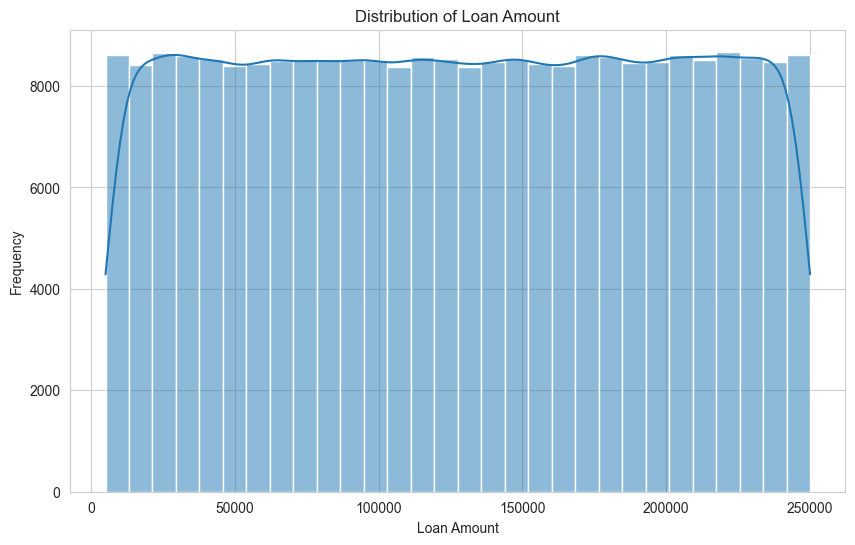

In [5]:
sns.set_style('whitegrid')

# Univariate Analysis: Histogram for Loan Amount
plt.figure(figsize=(10, 6))
sns.histplot(df['LoanAmount'], kde=True, bins=30)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

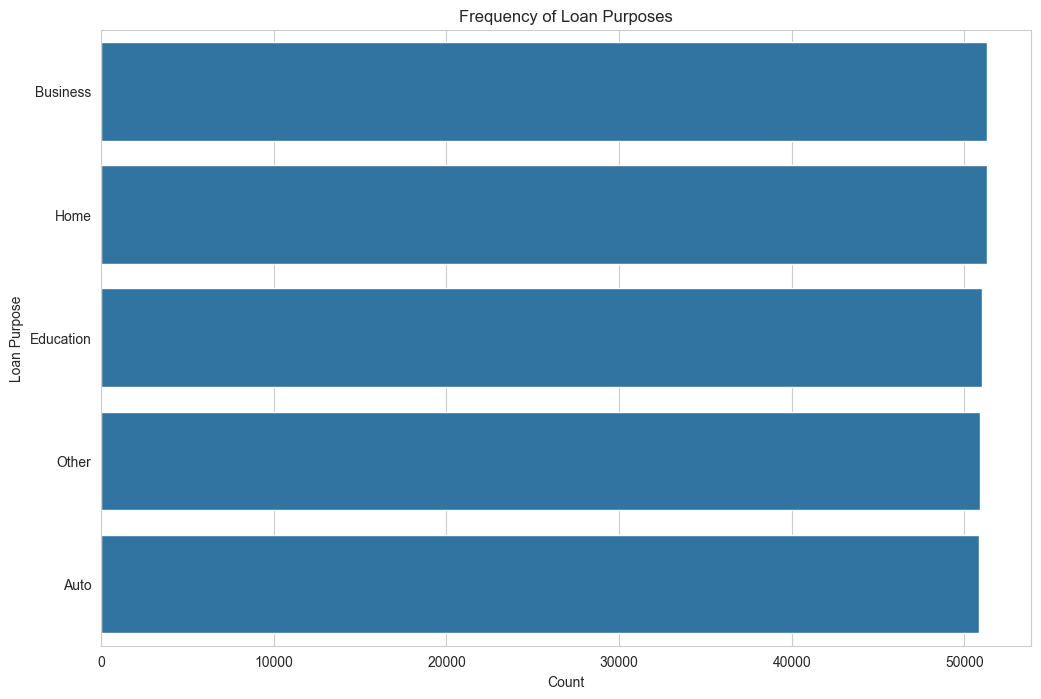

In [6]:
# Univariate Analysis: Bar Plot for Loan Purpose
plt.figure(figsize=(12, 8))
sns.countplot(y='LoanPurpose', data=df, order = df['LoanPurpose'].value_counts().index)
plt.title('Frequency of Loan Purposes')
plt.xlabel('Count')
plt.ylabel('Loan Purpose')
plt.show()

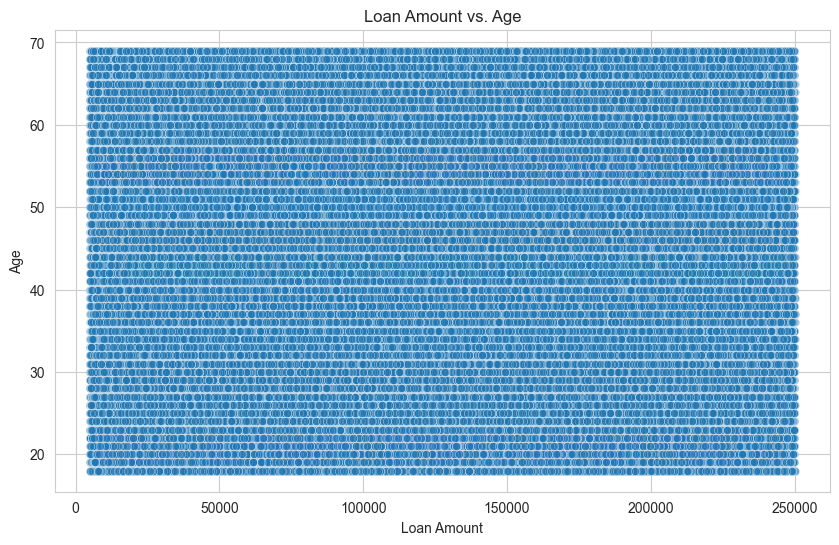

In [7]:
# Bivariate Analysis: Scatter Plot for Loan Amount vs. Interest Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='LoanAmount', y='Age', data=df, alpha=0.5)
plt.title('Loan Amount vs. Age')
plt.xlabel('Loan Amount')
plt.ylabel('Age')
plt.show()

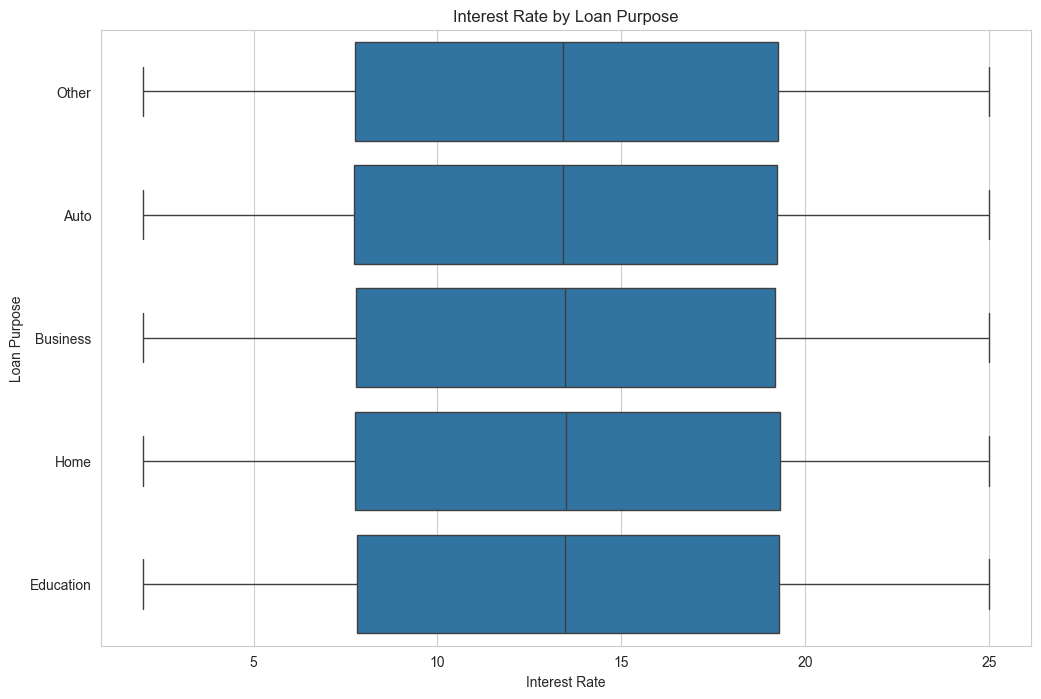

In [8]:
# Bivariate Analysis: Box Plot for Interest Rate by Loan Purpose
plt.figure(figsize=(12, 8))
sns.boxplot(y='LoanPurpose', x='InterestRate', data=df)
plt.title('Interest Rate by Loan Purpose')
plt.xlabel('Interest Rate')
plt.ylabel('Loan Purpose')
plt.show()

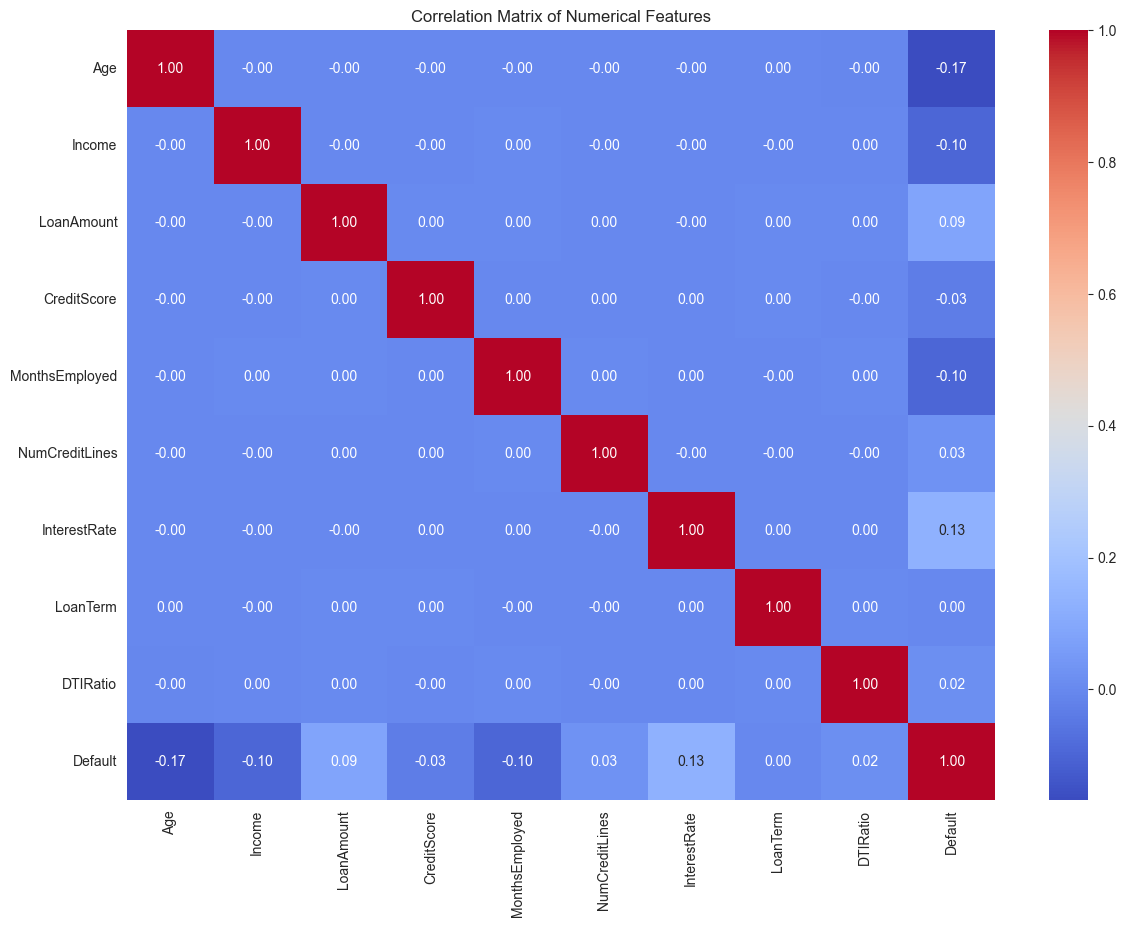

In [9]:
# Correlation Analysis: Heatmap
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
## Step 4: Drawing Conclusions

##Based on the analysis, here are some potential findings:

#1)Loan Purpose:** The majority of loans were taken for a specific purpose (e.g., `debt_consolidation` is often a common reason). The bar plot for loan purposes would confirm the most frequent category.
#2)Loan Amount Distribution:** The loan amounts are likely right-skewed, with a larger number of smaller loans and fewer very large loans. The histogram for loan amount would show this distribution.
#3)Interest Rate and Loan Amount:** There might be a slight positive correlation between the loan amount and the interest rate, which can be observed from the scatter plot. 
#4)Interest Rate by Purpose:** The box plot would likely show that interest rates vary significantly by the purpose of the loan. For example, loans for riskier ventures like `small_business` might have higher average interest rates compared to `credit_card` or `debt_consolidation` loans.
#5)Correlations:** The heatmap of the correlation matrix would highlight strong relationships between numerical variables. For instance, `loan_amount` and `installment` would be highly positively correlated.##